In [12]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt


In [13]:

@njit
def F(q, alpha, Q0, qf, k=30.0):
    # smooth step for at qf 
    smooth_step = 0.5 * (1.0 + np.tanh(k * (q - qf)))

    return alpha * (Q0 - q) * (q - qf) * smooth_step

@njit
def dF(q, alpha, Q0, qf, k=30.0):
    # smooth step for at qf 
    smooth_step = 0.5 * (1.0 + np.tanh(k * (q - qf)))
    dsmooth_step = 0.5 * k * (1.0 - np.tanh(k * (q - qf)) ** 2)

    return alpha * (-(q - qf) * smooth_step + (Q0 - q) * smooth_step + (Q0 - q) * (q - qf) * dsmooth_step)


In [ ]:

@njit
def solve(t, r, Z, alpha, Q0, qf, newton_iters=20, tol=1e-12, q=None):
    """
    Solve:
        q_n = dt * sum_{k=0}^n r_k * (q_{n-k} + Z F(q_{n-k})) + Z F(q_n)    
    """
    N = len(t)
    dt = t[1] - t[0]

    if q is None:
        q = np.zeros(N, dtype=np.float64)

    f = np.zeros(N, dtype=np.float64)
    qh = np.zeros(N, dtype=np.float64)

    r0 = r[0]
    nr = len(r) - 1

    for n in range(N):
        # History term excluding k=0, so it only uses past values
        hist = 0.0
        for k in range(1, nr + 1):
            j = n - k
            hist += r[k] * (q[j] + Z * f[j])
        hist *= dt

        # Solve scalar nonlinear equation for q[n]:
        # qn = hist + dt*r0*(qn + Z*F(qn)) + Z*F(qn)
        # Rearranged:
        # G(qn) = qn - hist - (1 + dt*r0)*Z*F(qn) - dt*r0*qn = 0
        qn = q[n - 1] if n > 0 else 0.0

        for _ in range(newton_iters):
            Fn = F(qn, alpha, Q0, qf)
            dFn = dF(qn, alpha, Q0, qf) 

            G = qn - hist - (1.0 + dt * r0) * Z * Fn - dt * r0 * qn
            dG = 1.0 - (1.0 + dt * r0) * Z * dFn - dt * r0

            step = G / dG
            qn_new = qn - step
            if abs(qn_new - qn) < tol:
                qn = qn_new
                break
            qn = qn_new

        q[n] = qn
        f[n] = F(qn, alpha, Q0, qf)
        qh[n] = hist + dt * r0 * (q[n] + Z * f[n])

    return q, f, qh


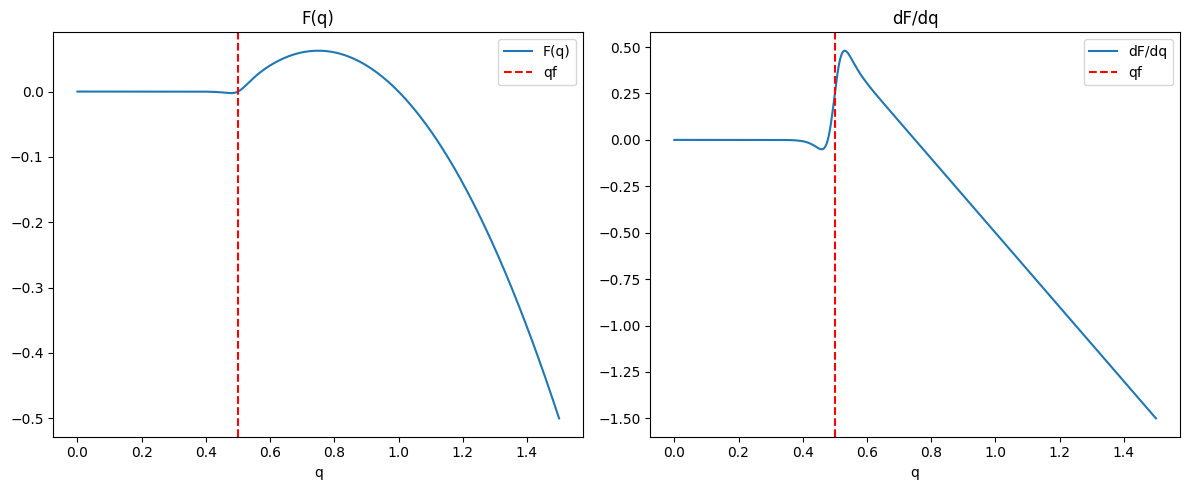

In [15]:
# plot F and dF to check they look correct

plt.figure(figsize=(12, 5))
alpha = 1.0
Q0 = 1.0
qf = 0.5
q = np.linspace(0, 1.5, 500)
F_vals = F(q, alpha, Q0, qf)
dF_vals = dF(q, alpha, Q0, qf)
plt.subplot(1, 2, 1)
plt.plot(q, F_vals, label='F(q)')
plt.axvline(qf, color='red', linestyle='--', label='qf')
plt.title('F(q)')
plt.xlabel('q')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(q, dF_vals, label='dF/dq')
plt.axvline(qf, color='red', linestyle='--', label='qf')
plt.title('dF/dq')
plt.xlabel('q')
plt.legend()
plt.tight_layout()
plt.show()


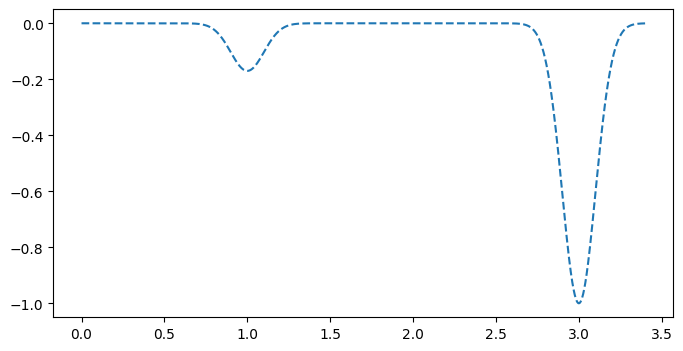

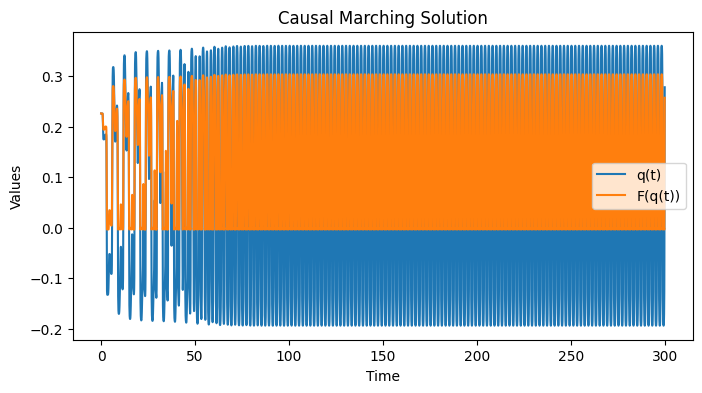

In [ ]:

dt = 1e-3
tmax = 300.0
t = np.arange(0.0, tmax + dt, dt)

T = 3
sigma = 0.1
cutoff = 4.0 * sigma

tr = np.arange(0.0, T + cutoff + dt, dt)
r = np.zeros_like(tr)
r = r + -np.exp(-0.5 * ((tr - T) / sigma) ** 2)
r = r + -np.exp(-0.5 * ((tr - T/3) / sigma) ** 2)*0.17
r[0] = 0.0

Z = 1
alpha = 0.25

N = len(t)
q = np.zeros(N, dtype=np.float64)

Q0 = 3
qf = -0.1

q, f, qh = solve(t, r, Z, alpha, Q0, qf, q=q, newton_iters=10)


plt.figure(figsize=(8, 4))
plt.plot(tr, r, label="r(t)", linestyle="dashed")


plt.figure(figsize=(8, 4))
plt.plot(t, q, label="q(t)")
plt.plot(t, f, label="F(q(t))")
plt.xlabel("Time")
plt.ylabel("Values")
plt.title("Causal Marching Solution")
plt.legend()
plt.show()

from IPython.display import Audio
# interpolate to 8000 hz, original time is in miliseconds
from scipy.interpolate import interp1d
fr = 8000
t_interp = np.arange(0.0, tmax/1000, 1/fr)
interp_func = interp1d(t/1000, q, kind='cubic')
q_interp = interp_func(t_interp)    
Audio(data=np.array(q_interp, dtype=np.float32), rate=fr)